In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import pandas as pd


In [2]:
# مسیر دیتاست
dataset_path ="C:\\Users\\Asus\\python lab\\dl\\brain_MRI_mobilenet\\Brain_Cancer"

In [3]:
weights_path = "C:\\Users\\Asus\\python lab\\dl\\brain_MRI_mobilenet\\model_weights\\mobilenet_v2_weights.h5"
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights=weights_path)

In [4]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 3

In [5]:
#بارگذاری داده‌ها
def load_dataset(dataset_path):
    X, y = [], []
    class_names = sorted(os.listdir(dataset_path))
    class_map = {name: idx for idx, name in enumerate(class_names)}

    for label in class_names:
        path = os.path.join(dataset_path, label)
        for fname in os.listdir(path):
            try:
                img_path = os.path.join(path, fname)
                img = load_img(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
                img_array = img_to_array(img)
                img_array = preprocess_input(img_array)
                X.append(img_array)
                y.append(class_map[label])
            except:
                continue
    X = np.array(X)
    y = tf.keras.utils.to_categorical(np.array(y), num_classes=len(class_names))
    return X, y, class_names

In [6]:
X, y, class_names = load_dataset(dataset_path)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# ======== ساخت مدل MobileNetV2 ==========
base_model = MobileNetV2(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
                         include_top=False,
                         weights=None)  # بدون دانلود

base_model.load_weights(weights_path)  # بارگذاری وزن‌ها از فایل محلی

base_model.trainable = False  # فریز کردن وزن‌ها

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
preds = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=preds)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [8]:
#آموزش مدل
history = model.fit(X_train, y_train, validation_split=0.1, epochs=EPOCHS, batch_size=BATCH_SIZE)

Epoch 1/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 109s 672ms/step - accuracy: 0.6565 - loss: 0.7770 - val_accuracy: 0.8990 - val_loss: 0.2978
Epoch 2/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 85s 624ms/step - accuracy: 0.8728 - loss: 0.3198 - val_accuracy: 0.9216 - val_loss: 0.2363
Epoch 3/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 84s 614ms/step - accuracy: 0.9197 - loss: 0.2459 - val_accuracy: 0.9299 - val_loss: 0.1986
Epoch 4/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 85s 624ms/step - accuracy: 0.9270 - loss: 0.2155 - val_accuracy: 0.9485 - val_loss: 0.1848
Epoch 5/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 91s 666ms/step - accuracy: 0.9204 - loss: 0.2161 - val_accuracy: 0.9423 - val_loss: 0.1896
Epoch 6/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 93s 681ms/step - accuracy: 0.9313 - loss: 0.1896 - val_accuracy: 0.9340 - val_loss: 0.1997
Epoch 7/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 90s 658ms/step - accuracy: 0.9265 - loss: 0.1946 - val_accuracy: 0.9505 - val_loss: 0.1620
Epoch 8/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 90s 654ms/step - accuracy: 0.9372 - loss: 

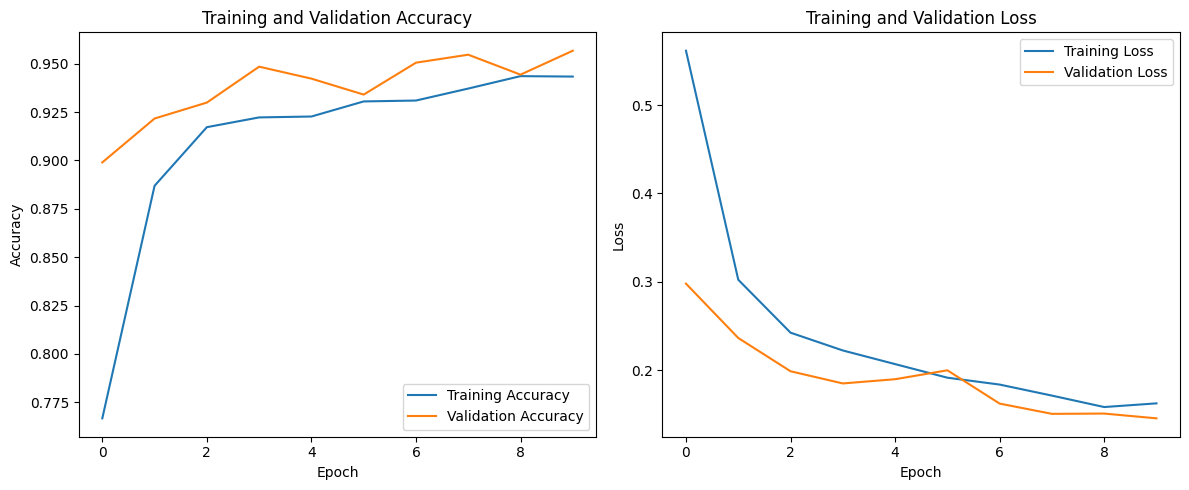

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
#testارزیابی
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc * 100:.2f}%")


38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 565ms/step - accuracy: 0.9421 - loss: 0.1539
Test Accuracy: 94.55%


In [10]:
#گزارش طبقه‌بندی
y_pred = model.predict(X_test)
print(classification_report(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1), target_names=class_names))

38/38 ━━━━━━━━━━━━━━━━━━━━ 30s 674ms/step
              precision    recall  f1-score   support

brain_glioma       0.99      0.96      0.97       425
 brain_menin       0.91      0.93      0.92       392
 brain_tumor       0.94      0.95      0.94       395

    accuracy                           0.95      1212
   macro avg       0.95      0.95      0.95      1212
weighted avg       0.95      0.95      0.95      1212



In [11]:
#  ذخیره مدل و وزن ها
model.save('mobile_net_brain_MRI.h5')  # فرمت HDF5
model.save_weights('my_model.weights.h5')

In [12]:
# مدل کامل
from tensorflow.keras.models import load_model
model = load_model('mobile_net_brain_MRI.h5')
# وزن‌ها
model.load_weights('my_model.weights.h5')

C:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [13]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np

# بارگذاری مدل آموزش‌دیده
model = load_model('mobile_net_brain_MRI.h5')  # یا مسیر مدل شما

#  مسیر تصویر برای نمونه جدید
image_path = "C:\\Users\\Asus\\python lab\\dl\\brain_MRI_mobilenet\\test_image\\4-year-old-boy-with-angiocentric-glioma-Axial-T2weighted-image-shows-a-hyperintense.png"
# پیش‌پردازش تصویر
image = load_img(image_path, target_size=(224, 224))       # تغییر سایز
image = img_to_array(image)                                # تبدیل به آرایه عددی
image = preprocess_input(image)                            # پیش‌پردازش مطابق MobileNetV2
image = np.expand_dims(image, axis=0)                      # اضافه کردن بعد batch → shape: (1, 224, 224, 3)

# پیش‌بینی
prediction = model.predict(image)
predicted_class_index = np.argmax(prediction, axis=1)[0]

class_names = ['Glioma', 'Meningioma', 'other tumor']  # مثال
predicted_label = class_names[predicted_class_index]

print(f" Predicted class: {predicted_label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
 Predicted class: Glioma


Confusion Matrix:
[[406  18   1]
 [  4 365  23]
 [  0  20 375]]


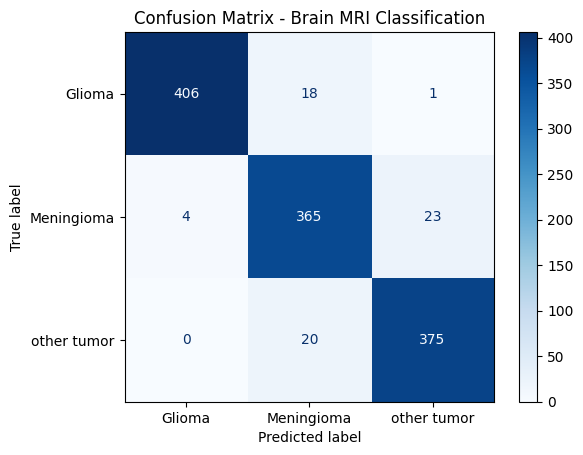

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# تبدیل One-Hot Encoding به شماره کلاس
y_true = np.argmax(y_test, axis=1)

# انتخاب کلاسی که بیشترین احتمال را دارد
y_pred_classes = np.argmax(y_pred, axis=1)

# ساخت Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

print("Confusion Matrix:")
print(cm)

# نمایش Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Brain MRI Classification")
plt.show()